# Pertemuan 9: Algoritma Klasifikasi
### Prediksi Diagnosis

| | |
|---|---|
| **Nama Lengkap** | Nisa Agustina Maesaroh |
| **NIM** | 240401070509 |
| **Kelas** | IF403 |

In [22]:
#Langkah 1: Load & EDA Singkat

from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target # 0=malignant, 1=benign
print('Shape:', X.shape)
print('Distribusi target:')
print(pd.Series(y).value_counts(normalize=True).round(3))

Shape: (569, 30)
Distribusi target:
1    0.627
0    0.373
Name: proportion, dtype: float64


In [23]:
#Langkah 2: Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'X Train s: {X_train_s}')
print(f'\nX Test s: {X_test_s}')

X Train s: [[-1.07200079 -0.6584246  -1.0880801  ... -1.35052668 -0.35265805
  -0.54138003]
 [ 1.74874285  0.06650173  1.75115682 ...  1.54991557  0.19107787
  -0.1737386 ]
 [-0.97473376 -0.93112416 -0.99770871 ... -1.70744192 -0.307734
  -1.21303263]
 ...
 [ 0.39844772  1.06867262  0.50751384 ...  1.53492543  0.16164487
   1.23754763]
 [ 0.85331409 -0.0380331   0.9054796  ...  2.10455077  0.31035897
   0.36249578]
 [-0.91179628 -0.82431683 -0.87666079 ... -0.51332734 -0.50756857
   1.30824791]]

X Test s: [[ 1.56851278  2.16401585  1.74286587 ...  1.20214432 -0.14043064
   0.90036171]
 [-0.84027641 -0.5970672  -0.8741735  ... -1.10124064 -0.81429139
  -0.71323608]
 [-0.07072262  1.19138742  0.03202768 ...  0.57255843  1.14997397
   1.86841162]
 ...
 [ 0.3583966  -0.44935493  0.48264098 ...  1.63386036  0.54117564
   1.91191948]
 [-0.41401799  1.07321761 -0.42314565 ...  0.06139464 -0.1280378
   0.64747227]
 [-0.6829327  -0.69932953 -0.66607058 ... -0.23615965 -0.16211811
  -0.20147486

In [24]:
#Langkah 3: Latih Logistic Regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)

coef_df = pd.DataFrame({'Fitur': X.columns,
'Koefisien': log_model.coef_[0]
}).sort_values('Koefisien', key=abs, ascending=False)
print(coef_df.head())

                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616


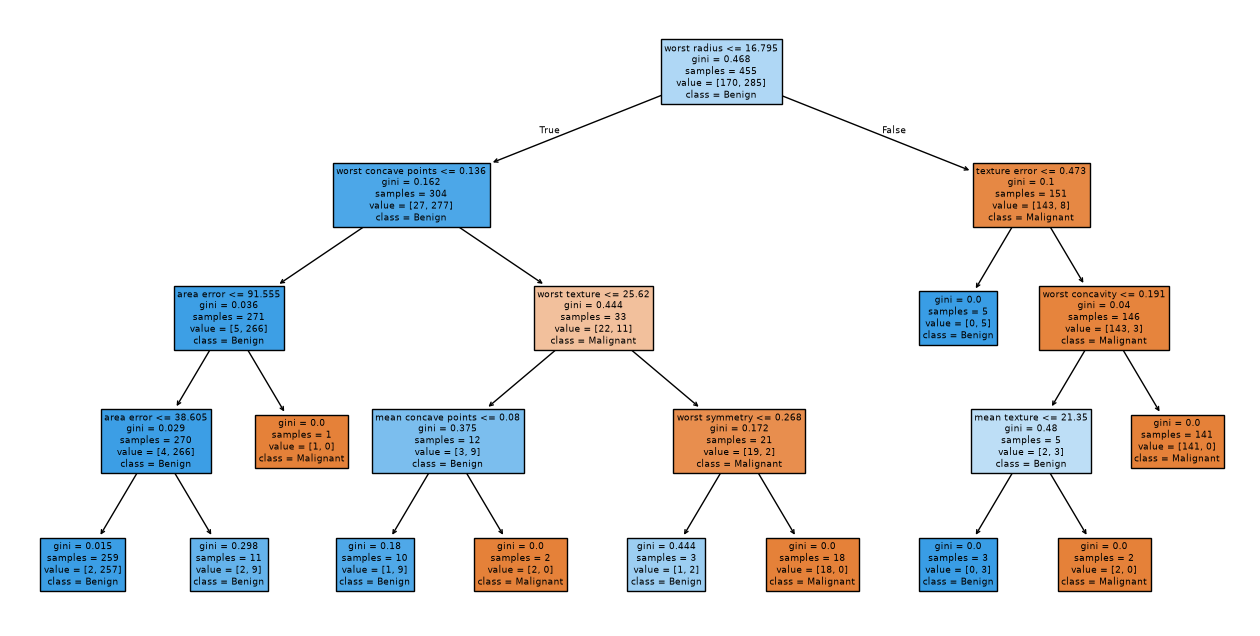

In [25]:
#Langkah 4: Latih Decision Tree

from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree_model = DecisionTreeClassifier(max_depth=4,
random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

plt.figure(figsize=(16, 8))
plot_tree(tree_model, feature_names=X.columns,
class_names=['Malignant','Benign'], filled=True)
plt.show()

In [26]:
#Langkah 5: Evaluasi & Bandingkan
from sklearn.metrics import (confusion_matrix,
accuracy_score, precision_score,
recall_score, f1_score)

for name, y_pred in [('Logistic Regression', y_pred_log),
('Decision Tree', y_pred_tree)]:
    print(f"\n=== {name} ===")
    print(confusion_matrix(y_test, y_pred))
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall : {recall_score(y_test, y_pred):.3f}")
    print(f"F1-Score : {f1_score(y_test, y_pred):.3f}")



=== Logistic Regression ===
[[41  1]
 [ 1 71]]
Accuracy : 0.982
Precision: 0.986
Recall : 0.986
F1-Score : 0.986

=== Decision Tree ===
[[39  3]
 [ 4 68]]
Accuracy : 0.939
Precision: 0.958
Recall : 0.944
F1-Score : 0.951


## Analisis: Recall vs Accuracy pada Diagnosis Kanker

**Model mana yang memiliki Recall lebih tinggi?**

Logistic Regression memiliki Recall lebih tinggi (0.986) dibandingkan Decision Tree (0.944). Pada confusion matrix, Logistic Regression hanya menghasilkan 1 False Negative, sedangkan Decision Tree menghasilkan 4 False Negative. Artinya, dari kasus yang sebenarnya positif (kelas yang menjadi fokus, sesuai label pada `y_pred`), Decision Tree empat kali lebih sering gagal mendeteksinya dibandingkan Logistic Regression pada data uji ini.

**Mengapa Recall menjadi metrik paling kritis untuk kasus diagnosis kanker dibandingkan Accuracy semata?**

Recall mengukur proporsi kasus positif aktual yang berhasil terdeteksi oleh model (TP / (TP + FN)). Dalam diagnosis kanker, False Negative (pasien yang sebenarnya sakit tapi diprediksi sehat) jauh lebih berbahaya dibandingkan False Positive (pasien sehat yang diprediksi sakit), karena:
- False Negative berarti pasien tidak mendapat penanganan lebih lanjut padahal kondisinya serius, yang berpotensi berakibat fatal dan terlambat ditangani.
- False Positive umumnya hanya berujung pada pemeriksaan tambahan (biopsi, tes lanjutan) yang lebih mahal/merepotkan namun tidak mengancam nyawa secara langsung.

Accuracy semata bisa menyesatkan, terutama pada dataset yang tidak seimbang. Pada kasus ini, distribusi target adalah 62.7% vs 37.3% — model yang asal menebak kelas mayoritas saja bisa mencapai Accuracy yang cukup tinggi tanpa benar-benar mendeteksi kasus minoritas dengan baik. Accuracy juga tidak membedakan jenis kesalahan (FN vs FP), padahal pada konteks medis kedua jenis kesalahan ini punya konsekuensi yang sangat tidak setara. Itulah sebabnya Recall (dan idealnya juga dianalisis bersama Precision/F1) menjadi metrik yang lebih relevan dibandingkan Accuracy saja.

**Apakah ada perbedaan signifikan antara performa kedua model?**

Secara numerik, Logistic Regression mengungguli Decision Tree pada semua metrik: Accuracy (0.982 vs 0.939), Precision (0.986 vs 0.958), Recall (0.986 vs 0.944), dan F1-Score (0.986 vs 0.951). Selisihnya berkisar 3-5 poin persentase di setiap metrik, yang pada konteks diagnosis medis cukup berarti karena setiap selisih Recall berhubungan langsung dengan jumlah pasien yang berpotensi terlewat.

Namun perlu dicatat beberapa keterbatasan dari kesimpulan ini:
- Evaluasi hanya dilakukan pada satu kali split train-test (bukan cross-validation), sehingga belum diketahui apakah selisih ini konsisten atau hanya kebetulan dari pembagian data tersebut.
- Jumlah sampel pada test set relatif kecil (114 data, terlihat dari total confusion matrix), sehingga selisih 3-4 kasus FN/FP bisa berdampak besar terhadap persentase metrik namun belum tentu signifikan secara statistik.
- Decision Tree dibatasi `max_depth=4`, yang dipilih untuk kemudahan visualisasi/interpretasi, bukan untuk performa optimal — sehingga perbandingan ini belum tentu mewakili performa Decision Tree terbaik yang bisa dicapai (misalnya dengan tuning `max_depth` atau menggunakan ensemble seperti Random Forest).

Kesimpulannya: secara praktis Logistic Regression tampak lebih unggul pada eksperimen ini, terutama dari sisi Recall yang krusial untuk kasus diagnosis kanker, tetapi untuk mengklaim perbedaan ini "signifikan secara statistik" perlu pengujian lebih lanjut seperti cross-validation atau uji statistik (misalnya McNemar's test) dibanding hanya membandingkan satu hasil split.

# Kesimpulan

## Apa yang Dipelajari

Praktikum ini menunjukkan alur kerja klasifikasi biner end-to-end: load dataset, EDA singkat untuk memeriksa keseimbangan kelas, preprocessing (split + standardisasi fitur), pelatihan dua model dengan karakteristik berbeda (Logistic Regression sebagai model linear, Decision Tree sebagai model berbasis aturan/non-linear), lalu evaluasi menggunakan confusion matrix dan empat metrik klasifikasi (Accuracy, Precision, Recall, F1-Score). Hal yang paling penting dipelajari adalah bahwa satu metrik tunggal (Accuracy) tidak cukup untuk menilai model pada konteks berisiko tinggi seperti diagnosis medis perlu dilihat metrik yang merepresentasikan jenis kesalahan secara spesifik.

## Temuan Utama

- Logistic Regression mengungguli Decision Tree di seluruh metrik pada eksperimen ini: Accuracy 0.982 vs 0.939, Precision 0.986 vs 0.958, Recall 0.986 vs 0.944, F1-Score 0.986 vs 0.951.
- Selisih Recall (0.986 vs 0.944) setara dengan selisih 3 False Negative (1 vs 4) pada 114 data uji — angka kecil yang berdampak besar secara persentase karena ukuran test set yang relatif kecil.
- Decision Tree dengan `max_depth=4` menghasilkan model yang mudah divisualisasikan dan diinterpretasi, namun trade-off-nya adalah error yang lebih banyak dibanding model linear pada kasus ini.
- Dataset breast cancer (sklearn) memiliki distribusi kelas yang cukup seimbang (62.7% vs 37.3%), sehingga Accuracy di sini masih cukup informatif, namun prinsip mengutamakan Recall tetap berlaku karena konsekuensi False Negative pada kasus medis, bukan karena Accuracy-nya tidak valid.

## Keterbatasan & Pertanyaan

- Evaluasi hanya berdasarkan satu kali train-test split (`random_state` tetap), bukan cross-validation — belum diketahui apakah keunggulan Logistic Regression konsisten di berbagai split atau hanya kebetulan dari pembagian data ini.
- Tidak ada uji signifikansi statistik (misalnya McNemar's test) untuk memastikan selisih performa antar model bukan sekadar noise dari sampel test yang kecil (114 data).
- Decision Tree dibatasi `max_depth=4` untuk kemudahan visualisasi, bukan hasil tuning hyperparameter — pertanyaan terbuka: apakah performanya akan menyamai atau melampaui Logistic Regression jika `max_depth` dioptimalkan (misalnya lewat GridSearchCV) atau diganti dengan ensemble seperti Random Forest/Gradient Boosting?
- Belum ada analisis terhadap kasus yang salah klasifikasi (false negative/false positive) secara individual — fitur apa yang membuat kasus-kasus tersebut sulit diprediksi oleh masing-masing model?
- Definisi positive class pada `recall_score`/`precision_score` mengikuti default scikit-learn (label 1). Perlu dipastikan label 1 memang merepresentasikan kelas yang relevan secara klinis (sesuai komentar `# 0=malignant, 1=benign` di Langkah 1), agar interpretasi Recall pada konteks "mendeteksi kanker" benar-benar akurat.